# Normal VS Cauchy

In [7]:
using DelimitedFiles, Statistics, Plots

In [8]:
# load datei
data = readdlm("/Users/gabrielwolf/Priv/Julia/WSKUE7/data.txt")[:, 1]

# mu udn sigma
mu    = mean(data)
sigma = std(data; corrected=false)
println("mu    = ", mu)
println("sigma = ", sigma)

# Warscheinlichkeitsdichte Funktion (pdf lol)
pdf_normal(x, mu, sigma) = (1 / (sigma * sqrt(2*pi))) * exp(-((x - mu)^2) / (2*sigma^2))
pdf_cauchy(x, mu, sigma) = (1 / pi) * (sigma / ((x - mu)^2 + sigma^2))

mu    = 8.03232654
sigma = 2.001489297113494


pdf_cauchy (generic function with 1 method)

logL_N = -211.28300852081878
logL_C = -235.8049382936161
BF = 4.464150072282814e10
Normal won


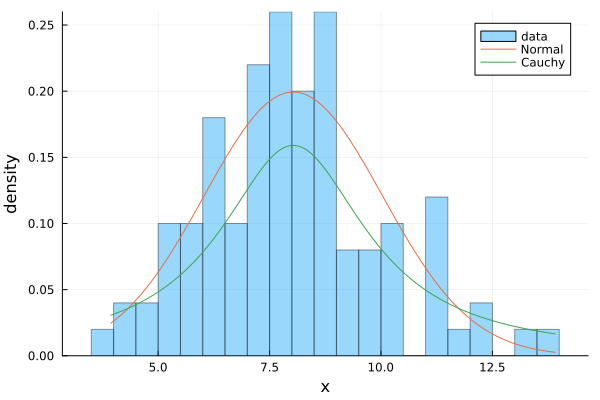

In [9]:
# Plot
histogram(data; bins=min(30, length(data) ÷ 3), normalize=:pdf, alpha=0.4, label="data")
xs = range(minimum(data), maximum(data); length=1000)
plot!(xs, pdf_normal.(xs, mu, sigma); label="Normal")
plot!(xs, pdf_cauchy.(xs, mu, sigma); label="Cauchy")
xlabel!("x"); ylabel!("density")

# LogLikelihoods
logL_N= sum(log.(pdf_normal.(data, mu, sigma)))
logL_C = sum(log.(pdf_cauchy.(data, mu, sigma)))

# Bayes-Faktor ohne rpiors
BF =exp(logL_N - logL_C)

println("logL_N = ", logL_N)
println("logL_C = ", logL_C)
println("BF = ", BF)
println(BF > 1 ? "Normal won" : "Cauchy won")

display(current())